# Entrenamiento de Conjunto de datos completo

In [1]:
#Importaciones
import warnings
warnings.filterwarnings("ignore")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler

#Lectura de datos
datos = pd.read_excel('03_Clusterizacion.xlsx')
datos.head(24)

,Fecha,Generación,Temperatura,Probabilidad Lluvia,Humedad Relativa,Índice UV,Condición Cielo,DPT,Hora,Cluster KMeans,Cluster GMM
0,2022-09-01 00:00:00,0.000000,19,7,77,0,4,15,0,Noche,Noche
1,2022-09-01 01:00:00,0.000000,19,7,82,0,4,16,1,Noche,Noche
2,2022-09-01 02:00:00,0.000000,18,9,85,0,3,16,2,Noche,Noche
3,2022-09-01 03:00:00,0.000000,18,11,87,0,3,16,3,Noche,Noche
4,2022-09-01 04:00:00,0.000000,18,11,88,0,3,16,4,Noche,Noche
5,2022-09-01 05:00:00,0.000000,17,15,86,0,3,14,5,Noche,Noche
6,2022-09-01 06:00:00,0.000000,18,47,89,0,3,16,6,Nublado,Lluvioso
7,2022-09-01 07:00:00,6.584959,18,51,95,0,4,17,7,Nublado,Lluvioso
8,2022-09-01 08:00:00,560.422022,18,47,100,0,3,18,8,Nublado,Lluvioso
9,2022-09-01 09:00:00,7720.582326,18,5,100,1,4,18,9,Nublado,Lluvioso


In [2]:
datos["Generacion_prev_hour"] = datos["Generación"].shift(1)
datos["Generacion_prev_day"] = datos["Generación"].shift(24)
datos = datos.dropna(how="any", axis= 0)

Definimos X y y

In [3]:
datos_dia = datos.copy()
datos_dia.head(10)

,Fecha,Generación,Temperatura,Probabilidad Lluvia,Humedad Relativa,Índice UV,Condición Cielo,DPT,Hora,Cluster KMeans,Cluster GMM,Generacion_prev_hour,Generacion_prev_day
24,2022-09-02 00:00:00,0.000000,19,6,76,0,4,15,0,Noche,Noche,0.000000,0.000000
25,2022-09-02 01:00:00,0.000000,18,7,81,0,4,15,1,Noche,Noche,0.000000,0.000000
26,2022-09-02 02:00:00,0.000000,18,7,84,0,4,15,2,Noche,Noche,0.000000,0.000000
27,2022-09-02 03:00:00,0.000000,18,7,86,0,4,15,3,Noche,Noche,0.000000,0.000000
28,2022-09-02 04:00:00,0.000000,17,7,86,0,4,15,4,Noche,Noche,0.000000,0.000000
29,2022-09-02 05:00:00,0.000000,17,7,88,0,4,15,5,Noche,Noche,0.000000,0.000000
30,2022-09-02 06:00:00,0.000000,17,7,91,0,4,15,6,Nublado,Lluvioso,0.000000,0.000000
31,2022-09-02 07:00:00,0.000000,17,7,94,0,3,16,7,Nublado,Lluvioso,0.000000,6.584959
32,2022-09-02 08:00:00,438.814997,16,5,97,0,3,15,8,Nublado,Lluvioso,0.000000,560.422022
33,2022-09-02 09:00:00,5908.000884,17,0,93,1,2,16,9,Nublado,Lluvioso,438.814997,7720.582326


In [4]:
columns = datos_dia.drop(columns=["Fecha", "Generación", "Cluster KMeans", "Cluster GMM"]).columns

In [5]:
X = datos_dia[columns]
X

,Temperatura,Probabilidad Lluvia,Humedad Relativa,Índice UV,Condición Cielo,DPT,Hora,Generacion_prev_hour,Generacion_prev_day
24,19,6,76,0,4,15,0,0.0,0.0
25,18,7,81,0,4,15,1,0.0,0.0
26,18,7,84,0,4,15,2,0.0,0.0
27,18,7,86,0,4,15,3,0.0,0.0
28,17,7,86,0,4,15,4,0.0,0.0
...,...,...,...,...,...,...,...,...,...
18285,22,0,45,0,1,9,20,1450.0,0.0
18286,20,0,54,0,1,10,21,0.0,0.0
18287,18,0,62,0,1,11,22,0.0,0.0
18288,17,0,69,0,1,11,23,0.0,0.0


In [6]:
y = datos_dia[['Generación']]
y

,Generación
24,0.0
25,0.0
26,0.0
27,0.0
28,0.0
...,...
18285,0.0
18286,0.0
18287,0.0
18288,0.0


Dividimos entrenamiento, validación y prueba

In [7]:
train_size = int(0.7 * len(X))
val_size = int(0.85 * len(X))

In [8]:
# Entrenamiento, validación y prueba, 75, 15 y 15
X_train, y_train =  X.iloc[:train_size, :], y.iloc[:train_size, :]
X_val, y_val = X.iloc[train_size:val_size, :], y.iloc[train_size:val_size, :]
X_test, y_test = X.iloc[val_size:, :],  y.iloc[val_size:,:]

print(f'X_train: {len(X_train)}, y_train: {len(y_train)}')
print(f'X_val: {len(X_val)}, y_val: {len(y_val)}')
print(f'X_test: {len(X_test)}, y_test: {len(y_test)}')

X_train: 12786, y_train: 12786
X_val: 2740, y_val: 2740
X_test: 2740, y_test: 2740


## Escalar con MinMaxScaler

In [9]:
from sklearn.preprocessing import MinMaxScaler

In [10]:
x_scaler = MinMaxScaler().fit(X_train)
x_scaler

MinMaxScaler()

In [11]:
X_train_scaled = x_scaler.transform(X_train)
print(X_train_scaled)
print(X_train_scaled.shape)

[[0.5        0.06666667 0.74736842 ... 0.         0.         0.        ]
 [0.47368421 0.07777778 0.8        ... 0.04347826 0.         0.        ]
 [0.47368421 0.07777778 0.83157895 ... 0.08695652 0.         0.        ]
 ...
 [0.36842105 0.68888889 0.77894737 ... 0.60869565 0.71913333 0.34156667]
 [0.36842105 0.54444444 0.75789474 ... 0.65217391 0.70556667 0.33793333]
 [0.36842105 0.65555556 0.72631579 ... 0.69565217 0.79483333 0.24856667]]
(12786, 9)


In [12]:
X_train_scaled_df = pd.DataFrame(X_train_scaled, index=X_train.index, columns=X_train.columns)
X_train_scaled_df

,Temperatura,Probabilidad Lluvia,Humedad Relativa,Índice UV,Condición Cielo,DPT,Hora,Generacion_prev_hour,Generacion_prev_day
24,0.500000,0.066667,0.747368,0.000000,0.75,0.789474,0.000000,0.000000,0.000000
25,0.473684,0.077778,0.800000,0.000000,0.75,0.789474,0.043478,0.000000,0.000000
26,0.473684,0.077778,0.831579,0.000000,0.75,0.789474,0.086957,0.000000,0.000000
27,0.473684,0.077778,0.852632,0.000000,0.75,0.789474,0.130435,0.000000,0.000000
28,0.447368,0.077778,0.852632,0.000000,0.75,0.789474,0.173913,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...
12805,0.342105,0.544444,0.736842,0.142857,1.00,0.473684,0.521739,0.843733,0.344767
12806,0.394737,0.544444,0.652632,0.142857,1.00,0.473684,0.565217,0.829000,0.338200
12807,0.368421,0.688889,0.778947,0.071429,1.00,0.526316,0.608696,0.719133,0.341567
12808,0.368421,0.544444,0.757895,0.071429,1.00,0.526316,0.652174,0.705567,0.337933


In [13]:
X_val_scaled = x_scaler.transform(X_val)
print(X_val_scaled)
print(X_val_scaled.shape)

[[0.34210526 0.63333333 0.72631579 ... 0.73913043 0.70433333 0.24723333]
 [0.34210526 0.54444444 0.69473684 ... 0.7826087  0.702      0.2108    ]
 [0.34210526 0.48888889 0.69473684 ... 0.82608696 0.4138     0.01416667]
 ...
 [0.81578947 0.07777778 0.25263158 ... 0.7826087  0.9109     0.82416667]
 [0.78947368 0.06666667 0.30526316 ... 0.82608696 0.82416667 0.45596667]
 [0.73684211 0.05555556 0.35789474 ... 0.86956522 0.46683333 0.0394    ]]
(2740, 9)


In [14]:
X_val_scaled_df = pd.DataFrame(X_val_scaled, index=X_val.index, columns=X_val.columns)
X_val_scaled_df

,Temperatura,Probabilidad Lluvia,Humedad Relativa,Índice UV,Condición Cielo,DPT,Hora,Generacion_prev_hour,Generacion_prev_day
12810,0.342105,0.633333,0.726316,0.000000,1.00,0.473684,0.739130,0.704333,0.247233
12811,0.342105,0.544444,0.694737,0.000000,1.00,0.421053,0.782609,0.702000,0.210800
12812,0.342105,0.488889,0.694737,0.000000,1.00,0.421053,0.826087,0.413800,0.014167
12813,0.315789,0.377778,0.726316,0.000000,0.75,0.368421,0.869565,0.043467,0.000000
12814,0.289474,0.377778,0.768421,0.000000,0.50,0.368421,0.913043,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...
15545,0.894737,0.077778,0.178947,0.357143,0.00,0.473684,0.695652,0.959467,0.935400
15546,0.868421,0.077778,0.200000,0.214286,0.25,0.473684,0.739130,0.940767,0.910900
15547,0.815789,0.077778,0.252632,0.142857,0.50,0.578947,0.782609,0.910900,0.824167
15548,0.789474,0.066667,0.305263,0.071429,0.25,0.631579,0.826087,0.824167,0.455967


In [15]:
X_test_scaled = x_scaler.transform(X_test)
print(X_test_scaled)
print(X_test_scaled.shape)

[[0.68421053 0.05555556 0.42105263 ... 0.91304348 0.0379     0.        ]
 [0.65789474 0.05555556 0.49473684 ... 0.95652174 0.         0.        ]
 [0.60526316 0.05555556 0.56842105 ... 1.         0.         0.        ]
 ...
 [0.47368421 0.         0.6        ... 0.95652174 0.         0.        ]
 [0.44736842 0.         0.67368421 ... 1.         0.         0.        ]
 [0.42105263 0.         0.71578947 ... 0.         0.         0.        ]]
(2740, 9)


In [16]:
X_test_scaled_df = pd.DataFrame(X_test_scaled, index=X_test.index, columns=X_test.columns)
X_test_scaled_df

,Temperatura,Probabilidad Lluvia,Humedad Relativa,Índice UV,Condición Cielo,DPT,Hora,Generacion_prev_hour,Generacion_prev_day
15550,0.684211,0.055556,0.421053,0.0,0.0,0.736842,0.913043,0.037900,0.0
15551,0.657895,0.055556,0.494737,0.0,0.0,0.736842,0.956522,0.000000,0.0
15552,0.605263,0.055556,0.568421,0.0,0.0,0.789474,1.000000,0.000000,0.0
15553,0.578947,0.055556,0.600000,0.0,0.0,0.789474,0.000000,0.000000,0.0
15554,0.578947,0.044444,0.631579,0.0,0.0,0.789474,0.043478,0.000000,0.0
...,...,...,...,...,...,...,...,...,...
18285,0.578947,0.000000,0.421053,0.0,0.0,0.473684,0.869565,0.048333,0.0
18286,0.526316,0.000000,0.515789,0.0,0.0,0.526316,0.913043,0.000000,0.0
18287,0.473684,0.000000,0.600000,0.0,0.0,0.578947,0.956522,0.000000,0.0
18288,0.447368,0.000000,0.673684,0.0,0.0,0.578947,1.000000,0.000000,0.0


In [17]:
x_scaller_all = MinMaxScaler().fit(X)
print(x_scaller_all)

MinMaxScaler()


In [18]:
X_scaled = x_scaller_all.transform(X)
print(X_scaled)
print(X_scaled.shape)

[[0.48717949 0.06666667 0.75257732 ... 0.         0.         0.        ]
 [0.46153846 0.07777778 0.80412371 ... 0.04347826 0.         0.        ]
 [0.46153846 0.07777778 0.83505155 ... 0.08695652 0.         0.        ]
 ...
 [0.46153846 0.         0.60824742 ... 0.95652174 0.         0.        ]
 [0.43589744 0.         0.68041237 ... 1.         0.         0.        ]
 [0.41025641 0.         0.72164948 ... 0.         0.         0.        ]]
(18266, 9)


In [19]:
X_scaled_df = pd.DataFrame(X_scaled, index=X.index, columns=X.columns)
X_scaled_df

,Temperatura,Probabilidad Lluvia,Humedad Relativa,Índice UV,Condición Cielo,DPT,Hora,Generacion_prev_hour,Generacion_prev_day
24,0.487179,0.066667,0.752577,0.0,0.75,0.75,0.000000,0.000000,0.0
25,0.461538,0.077778,0.804124,0.0,0.75,0.75,0.043478,0.000000,0.0
26,0.461538,0.077778,0.835052,0.0,0.75,0.75,0.086957,0.000000,0.0
27,0.461538,0.077778,0.855670,0.0,0.75,0.75,0.130435,0.000000,0.0
28,0.435897,0.077778,0.855670,0.0,0.75,0.75,0.173913,0.000000,0.0
...,...,...,...,...,...,...,...,...,...
18285,0.564103,0.000000,0.432990,0.0,0.00,0.45,0.869565,0.048333,0.0
18286,0.512821,0.000000,0.525773,0.0,0.00,0.50,0.913043,0.000000,0.0
18287,0.461538,0.000000,0.608247,0.0,0.00,0.55,0.956522,0.000000,0.0
18288,0.435897,0.000000,0.680412,0.0,0.00,0.55,1.000000,0.000000,0.0


In [20]:
y_scaler = MinMaxScaler().fit(y_train)
print(y_scaler)

MinMaxScaler()


In [21]:
y_train_scaled = y_scaler.transform(y_train)
print(y_train_scaled)
print(y_train_scaled.shape)

[[0.        ]
 [0.        ]
 [0.        ]
 ...
 [0.70556667]
 [0.79483333]
 [0.70433333]]
(12786, 1)


In [22]:
y_train_scaled_df = pd.DataFrame(y_train_scaled, index=y_train.index, columns=y_train.columns)
y_train_scaled_df

,Generación
24,0.000000
25,0.000000
26,0.000000
27,0.000000
28,0.000000
...,...
12805,0.829000
12806,0.719133
12807,0.705567
12808,0.794833


In [23]:
y_val_scaled = y_scaler.transform(y_val)
print(y_val_scaled)
print(y_val_scaled.shape)

[[0.702     ]
 [0.4138    ]
 [0.04346667]
 ...
 [0.82416667]
 [0.46683333]
 [0.0379    ]]
(2740, 1)


In [24]:
y_val_scaled_df = pd.DataFrame(y_val_scaled, index=y_val.index, columns=y_val.columns)
y_val_scaled_df

,Generación
12810,0.702000
12811,0.413800
12812,0.043467
12813,0.000000
12814,0.000000
...,...
15545,0.940767
15546,0.910900
15547,0.824167
15548,0.466833


In [25]:
y_test_scaled = y_scaler.transform(y_test)
print(y_test_scaled)
print(y_test_scaled.shape)

[[0.]
 [0.]
 [0.]
 ...
 [0.]
 [0.]
 [0.]]
(2740, 1)


In [26]:
y_test_scaled_df = pd.DataFrame(y_test_scaled, index=y_test.index, columns=y_test.columns)
y_test_scaled_df

,Generación
15550,0.0
15551,0.0
15552,0.0
15553,0.0
15554,0.0
...,...
18285,0.0
18286,0.0
18287,0.0
18288,0.0


In [27]:
y_scaller_all = MinMaxScaler().fit(y)
print(y_scaller_all)

MinMaxScaler()


In [28]:
y_scaled = y_scaller_all.transform(y)
print(y_scaled)
print(y_scaled.shape)

[[0.]
 [0.]
 [0.]
 ...
 [0.]
 [0.]
 [0.]]
(18266, 1)


In [29]:
y_scaled_df = pd.DataFrame(y_scaled, index=y.index, columns=y.columns)
y_scaled_df

,Generación
24,0.0
25,0.0
26,0.0
27,0.0
28,0.0
...,...
18285,0.0
18286,0.0
18287,0.0
18288,0.0


## Preparación para redes neuronales

In [30]:
import numpy as np
import pandas as pd

def create_sliding_window_with_index(data_X, data_y, lookback):
    X, y, indices = [], [], []

    # Asegurar que `data_y` tiene los mismos índices que `data_X`
    data_y = data_y.reindex(data_X.index)

    max_index = len(data_X) - lookback

    for i in range(max_index):
        X.append(data_X.iloc[i:i + lookback].values)  # Ventana de entrada

        # Obtener el índice correcto en `data_y`
        y_index = data_X.index[i + lookback]

        # Extraer el valor correspondiente de `data_y`
        if y_index in data_y.index:
            y_value = data_y.loc[y_index]
            if isinstance(y_value, pd.Series):  # Si devuelve una serie, extraer el valor
                y_value = y_value.iloc[0]
        else:
            y_value = np.nan  # Si no está, asignamos NaN

        y.append(y_value)
        indices.append(y_index)  # 🔹 Guardamos el índice original de `data_y`

    # Convertimos `X` en un array y `y` en DataFrame conservando sus índices originales
    X_array = np.array(X)
    y_df = pd.DataFrame(y, index=indices, columns=['y'])  # 🔹 Conservamos los índices originales

    return X_array, y_df

In [31]:
lookback = 48

# Aplicar la ventana deslizante a cada conjunto
X_train_windowed, y_train_windowed = create_sliding_window_with_index(X_train_scaled_df, y_train_scaled_df, lookback)
X_val_windowed, y_val_windowed = create_sliding_window_with_index(X_val_scaled_df, y_val_scaled_df, lookback)
X_test_windowed, y_test_windowed = create_sliding_window_with_index(X_test_scaled_df, y_test_scaled_df, lookback)

In [32]:
print(f'X_train: {X_train_windowed.shape}, y_train: {y_train_windowed.shape}')
print(f'X_val: {X_val_windowed.shape}, y_val: {y_val_windowed.shape}')
print(f'X_test: {X_test_windowed.shape}, y_test: {y_test_windowed.shape}')

X_train: (12738, 48, 9), y_train: (12738, 1)
X_val: (2692, 48, 9), y_val: (2692, 1)
X_test: (2692, 48, 9), y_test: (2692, 1)


## Definición de Generación Naive

In [ ]:
predicciones = y_test.copy()
predicciones["Generacion_Naive"] = predicciones["Generación"].shift(1)
predicciones

## Definición de modelos

In [33]:
from lightgbm import LGBMRegressor
from sklearn.ensemble import RandomForestRegressor
import optuna
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score
import seaborn as sns
from sklearn.metrics import mean_absolute_percentage_error as mean_absolute_percentage_error
from sklearn.metrics import mean_absolute_error as mean_absolute_error
from sklearn.metrics import mean_squared_error as mean_squared_error
from sklearn.metrics import r2_score as r2_score
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping

In [58]:
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

### Light GBM

In [ ]:
LightGBM_model = LGBMRegressor(num_leaves=14, subsample= 0.3412949971354309, colsample_bytree= 0.34190269422505076, min_data_in_leaf= 85)
LightGBM_model.fit(X_train_scaled_df, y_train_scaled_df)

In [56]:
# Definir el modelo con los hiperparámetros actuales
RF_model = RandomForestRegressor(
    n_estimators=400,
    max_depth=50,
    min_samples_split=4,
    min_samples_leaf=10,
    bootstrap=True,
    criterion="squared_error"
)
RF_model.fit(X_train_scaled_df, y_train_scaled_df)

RandomForestRegressor(max_depth=50, min_samples_leaf=10, min_samples_split=4,
                      n_estimators=400)

### CT NET

In [50]:
def compile_and_fit(model, xtrain=X_train_windowed, ytrain=y_train_windowed, learning_rate=0.0001):
    model.compile(loss=[tf.keras.losses.MeanSquaredError()],
                  optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
                  metrics=[tf.keras.metrics.RootMeanSquaredError(), tf.keras.metrics.MeanAbsolutePercentageError(), tf.keras.metrics.MeanAbsoluteError()])
    
    history = model.fit(xtrain, ytrain, epochs=50,
                        batch_size=512, validation_split=0.2, verbose=1)
    return history

def Loss(train_loss, valid_loss):
    plt.plot(train_loss)
    plt.plot(valid_loss)
    plt.rcParams["figure.figsize"] = (15, 3)
    plt.title('Model Losses')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend(['Train Loss', 'Validation Loss'], loc='upper left')
    plt.savefig('out/loss_plot.png')
    plt.show()

def transformer_encoder(inputs, head_size, num_heads, ff_dim, dropout=0):
    x = layers.LayerNormalization()(inputs)
    x = layers.Conv1D(filters=ff_dim, kernel_size=1, activation="relu", padding="same")(x)
    x = layers.Conv1D(filters=128, kernel_size=2, activation="relu", padding="same")(x)
    x = layers.Conv1D(filters=inputs.shape[-1], kernel_size=1)(x)
    res = x + inputs
    norm_x = layers.LayerNormalization()(res)
    x = layers.MultiHeadAttention(key_dim=head_size, num_heads=num_heads, dropout=dropout)(norm_x, norm_x)
    res = x + inputs
    norm_x = layers.LayerNormalization()(res)
    return norm_x

# Construir modelo con hiperparámetros sugeridos
def build_model(input_shape, head_size, num_heads, ff_dim, num_transformer_blocks, mlp_units, dropout, mlp_dropout):
    inputs = tf.keras.Input(shape=input_shape)
    x = inputs

    for _ in range(num_transformer_blocks):
        x = transformer_encoder(x, head_size, num_heads, ff_dim, dropout)

    x = layers.MultiHeadAttention(key_dim=head_size, num_heads=num_heads, dropout=dropout)(x, x)
    x = layers.LayerNormalization(epsilon=1e-6)(x)
    x = layers.GlobalAveragePooling1D(data_format="channels_first")(x)
    
    for units in mlp_units:
        x = layers.Dense(units, activation="relu")(x)

    x = layers.Dropout(mlp_dropout)(x)
    outputs = layers.Dense(1)(x)
    return tf.keras.Model(inputs, outputs)

In [62]:
# Construir el modelo
CTNET_model = build_model(
    input_shape=(X_train_windowed.shape[1], X_train_windowed.shape[2]),
    head_size=2,
    num_heads=7,
    ff_dim=80,
    num_transformer_blocks=1,
    mlp_units=[192,128],
    dropout=0.4987492446198915,
    mlp_dropout=0.2048079774950788
)
# Compilar y entrenar el modelo
CTNET_model.compile(
    loss=tf.keras.losses.MeanSquaredError(),
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.004694195402090184),
    metrics=[tf.keras.metrics.RootMeanSquaredError()]
)
CTNET_history = CTNET_model.fit(
        X_train_windowed, y_train_windowed,
        validation_data=(X_val_windowed, y_val_windowed),  # 🔹 Validación en cada época
        epochs=100,  # Reducimos para exploración rápida
        batch_size=128,  # Ahora se usa el batch_size seleccionado por Optuna
        callbacks=[early_stop],  # 🔹 Early Stopping activado
        verbose=1  # Silenciamos el output para reducir logs
    )

Epoch 1/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 25s 157ms/step - loss: 0.1495 - root_mean_squared_error: 0.3862 - val_loss: 0.0259 - val_root_mean_squared_error: 0.1611
Epoch 2/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 16s 161ms/step - loss: 0.0214 - root_mean_squared_error: 0.1455 - val_loss: 0.0070 - val_root_mean_squared_error: 0.0837
Epoch 3/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 22s 177ms/step - loss: 0.0118 - root_mean_squared_error: 0.1087 - val_loss: 0.0088 - val_root_mean_squared_error: 0.0940
Epoch 4/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 16s 163ms/step - loss: 0.0104 - root_mean_squared_error: 0.1020 - val_loss: 0.0059 - val_root_mean_squared_error: 0.0768
Epoch 5/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 20s 159ms/step - loss: 0.0101 - root_mean_squared_error: 0.1003 - val_loss: 0.0053 - val_root_mean_squared_error: 0.0727
Epoch 6/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 16s 158ms/step - loss: 0.0094 - root_mean_squared_error: 0.0971 - val_loss: 0.0050 - val_root_mean_squared_error: 0.0705
Epoch 7/100
100/100 ━━━━━━━━

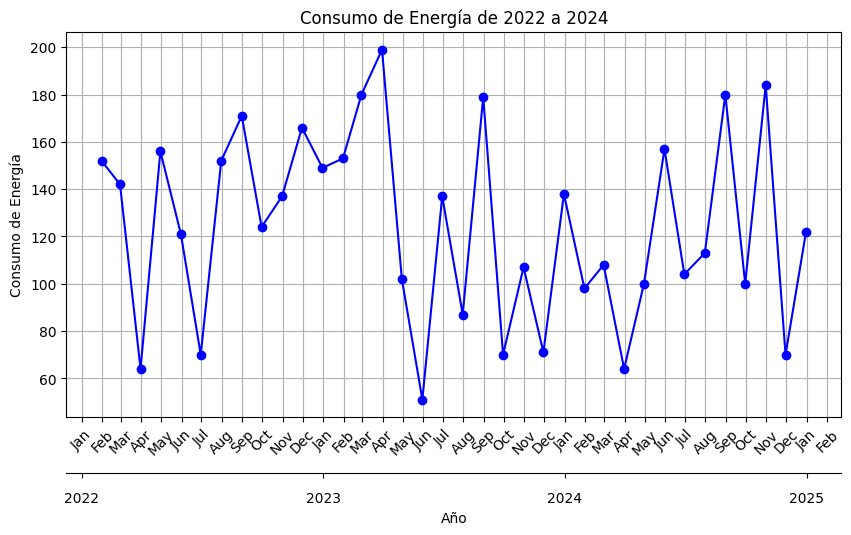

In [63]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Crear datos ficticios
np.random.seed(42)
fechas = pd.date_range(start="2022-01-01", end="2024-12-31", freq="M")
energia = np.random.randint(50, 200, size=len(fechas))

# Crear DataFrame
df = pd.DataFrame({"Fecha": fechas, "Energía": energia})

# Crear la figura
fig, ax = plt.subplots(figsize=(10, 5))

# Graficar la serie temporal
ax.plot(df["Fecha"], df["Energía"], marker="o", linestyle="-", color="b")

# Formato del eje X: mostrar meses y agrupar por año
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))  # Mostrar cada mes
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))  # Mostrar nombre del mes
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)  # Rotar etiquetas de los meses

# Agregar el eje secundario abajo para los años
ax_years = ax.secondary_xaxis('bottom')
ax_years.xaxis.set_major_locator(mdates.YearLocator())  # Marcar cada año
ax_years.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))  # Formato del año
ax_years.set_xlabel("Año")  # Etiqueta del eje secundario

# Ajustar la posición del eje de los años para que no se empalme
ax_years.spines['bottom'].set_position(('outward', 40))  # Mueve los años más abajo
ax_years.tick_params(pad=10)  # Aumentar el espacio entre los números y el eje

# Mejoras en la gráfica
#ax.set_xlabel("Mes del Año")
ax.set_ylabel("Consumo de Energía")
ax.set_title("Consumo de Energía de 2022 a 2024")
ax.grid(True)

# Mostrar la gráfica
plt.show()

### Forecasting

In [60]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import InputLayer, Conv1D, BatchNormalization, MaxPooling1D, Bidirectional, LSTM, Dropout, Dense
from tensorflow.keras.optimizers import Adam
# Construcción del modelo
Forecasting_model = Sequential()
Forecasting_model.add(InputLayer((X_train_windowed.shape[1], X_train_windowed.shape[2])))

# CNN
Forecasting_model.add(Conv1D(filters=128, kernel_size=5, padding='same', activation='relu'))
Forecasting_model.add(BatchNormalization())
Forecasting_model.add(MaxPooling1D(pool_size=2))

# BiLSTM
Forecasting_model.add(Bidirectional(LSTM(64, return_sequences=True)))
Forecasting_model.add(Bidirectional(LSTM(128, return_sequences=True)))
Forecasting_model.add(Dropout(0.40086998693335835))
Forecasting_model.add(Bidirectional(LSTM(64, return_sequences=False)))

# Normalización y Dropout
Forecasting_model.add(BatchNormalization())
Forecasting_model.add(Dropout(0.41776351065139583))

# Capas Densas
Forecasting_model.add(Dense(16, activation='relu'))
Forecasting_model.add(Dense(1, activation='relu'))

# Compilar el modelo
Forecasting_model.compile(
    loss=tf.keras.losses.MeanSquaredError(),
    optimizer=Adam(learning_rate=0.0012316082606971734),
    metrics=[tf.keras.metrics.RootMeanSquaredError()]
)

# Entrenar el modelo con validación
Forecasting_history = Forecasting_model.fit(
    X_train_windowed, y_train_windowed,
    epochs=100,  # Se puede detener antes con Early Stopping
    batch_size=128,  # 🔹 Batch size optimizado
    validation_data=(X_val_windowed, y_val_windowed),  # 🔹 Validación en cada época
    callbacks=[early_stop],  # 🔹 Early Stopping activado
    verbose=1
)

Epoch 1/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 37s 264ms/step - loss: 0.2193 - root_mean_squared_error: 0.4626 - val_loss: 0.1362 - val_root_mean_squared_error: 0.3691
Epoch 2/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 40s 254ms/step - loss: 0.0343 - root_mean_squared_error: 0.1847 - val_loss: 0.1211 - val_root_mean_squared_error: 0.3480
Epoch 3/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 24s 242ms/step - loss: 0.0212 - root_mean_squared_error: 0.1457 - val_loss: 0.0887 - val_root_mean_squared_error: 0.2978
Epoch 4/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 29s 287ms/step - loss: 0.0149 - root_mean_squared_error: 0.1219 - val_loss: 0.0332 - val_root_mean_squared_error: 0.1821
Epoch 5/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 47s 341ms/step - loss: 0.0127 - root_mean_squared_error: 0.1125 - val_loss: 0.0173 - val_root_mean_squared_error: 0.1315
Epoch 6/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 32s 318ms/step - loss: 0.0116 - root_mean_squared_error: 0.1078 - val_loss: 0.0114 - val_root_mean_squared_error: 0.1066
Epoch 7/100
100/100 ━━━━━━━━

### Photovoltaic

In [61]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, Bidirectional, GRU, MultiHeadAttention
from tensorflow.keras.layers import Flatten, Dropout, Dense
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import mean_squared_error

# Definir el modelo
inputs = Input(shape=(X_train_windowed.shape[1], X_train_windowed.shape[2]))

# Primera capa CNN
x = Conv1D(filters=128, kernel_size=3, padding='same', activation='relu')(inputs)
x = MaxPooling1D(pool_size=2)(x)

# Segunda capa CNN
x = Conv1D(filters=128, kernel_size=3, padding='same', activation='relu')(x)
x = MaxPooling1D(pool_size=2)(x)

# Capa BiGRU
x = Bidirectional(GRU(64, return_sequences=True))(x)

# Atención MultiHead
attention = MultiHeadAttention(num_heads=2, key_dim=128)(x, x)

# Aplanar y Dropout
x = Flatten()(attention)
x = Dropout(0.36428579949557205)(x)
x = Dense(128, activation="relu", kernel_regularizer=l2(0.01))(x)
x = Dense(32, activation="relu")(x)

# Capa de salida
outputs = Dense(1, activation="linear")(x)

# Construcción del modelo
Photovoltaic_model = Model(inputs=inputs, outputs=outputs)

# Compilar el modelo
Photovoltaic_model.compile(
    loss=tf.keras.losses.MeanSquaredError(),
    optimizer=Adam(learning_rate=0.00029394651991630923),
    metrics=[tf.keras.metrics.RootMeanSquaredError()]
)

history = Photovoltaic_model.fit(
    X_train_windowed, y_train_windowed,
    epochs=100,  # Se detendrá con Early Stopping
    batch_size=128,
    validation_data=(X_val_windowed, y_val_windowed),
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 23s 128ms/step - loss: 1.8704 - root_mean_squared_error: 0.3776 - val_loss: 0.5203 - val_root_mean_squared_error: 0.1201
Epoch 2/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 116ms/step - loss: 0.3671 - root_mean_squared_error: 0.1251 - val_loss: 0.0938 - val_root_mean_squared_error: 0.0950
Epoch 3/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 117ms/step - loss: 0.0686 - root_mean_squared_error: 0.1076 - val_loss: 0.0195 - val_root_mean_squared_error: 0.0826
Epoch 4/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 11s 111ms/step - loss: 0.0193 - root_mean_squared_error: 0.1025 - val_loss: 0.0093 - val_root_mean_squared_error: 0.0817
Epoch 5/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 11s 107ms/step - loss: 0.0118 - root_mean_squared_error: 0.0988 - val_loss: 0.0064 - val_root_mean_squared_error: 0.0730
Epoch 6/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 14s 142ms/step - loss: 0.0101 - root_mean_squared_error: 0.0951 - val_loss: 0.0058 - val_root_mean_squared_error: 0.0712
Epoch 7/100
100/100 ━━━━━━━━

## Predicciones con datos de entrenamiento

### Light GBM

In [ ]:
# Inicializar DataFrame de resultados
resultados = pd.DataFrame(index=y_train_scaled_df.index, columns=["LightGBM"])
# Predicción diaria con ciclo
for i in range(len(X_train)):
    inicio = i * 1
    fin = inicio + 1

    X_test_seg = X_train_scaled_df.iloc[inicio:fin, :]
    y_test_seg = y_train_scaled_df.iloc[inicio:fin]

    if len(X_test_seg) < 1:
        break

    y_pred = LightGBM_model.predict(X_test_seg)
    y_pred = y_scaler.inverse_transform(y_pred.reshape(-1, 1))
    y_pred = np.clip(y_pred, 0, 30000)  # 🔹 Limitamos entre 0 y 30,000

    resultados.iloc[i, 0] = y_pred[0, 0]

predicciones = y_train.copy()
predicciones["LightGBM_tr"] = resultados["LightGBM"]

### Random Forest

In [ ]:
# Inicializar DataFrame de resultados
resultados = pd.DataFrame(index=y_train_scaled_df.index, columns=["RandomForest"])
# Predicción diaria con ciclo
for i in range(len(X_train)):
    inicio = i * 1
    fin = inicio + 1

    X_test_seg = X_train_scaled_df.iloc[inicio:fin, :]
    y_test_seg = y_train_scaled_df.iloc[inicio:fin]

    if len(X_test_seg) < 1:
        break

    y_pred = RF_model.predict(X_test_seg)
    y_pred = y_scaler.inverse_transform(y_pred.reshape(-1, 1))
    y_pred = np.clip(y_pred, 0, 30000)  # 🔹 Limitamos entre 0 y 30,000

    resultados.iloc[i, 0] = y_pred[0, 0]

predicciones = y_train.copy()
predicciones["RandomForest_tr"] = resultados["RandomForest"]

### CTNET

In [ ]:
predictions_train = CTNET_model.predict(X_train_windowed)
predictions_train = y_scaler.inverse_transform(predictions_train.reshape(-1, 1))
predictions_train = np.clip(predictions_train, 0, 30000)  # 🔹 Limitamos entre 0 y 30,000
resultados_train = pd.DataFrame(predictions_train, index = y_train_windowed.index, columns=["CTNET"])
predicciones = y_train.copy()
predicciones["CTNET_tr"] = resultados_train["CTNET"]
predicciones

### Forecasting

In [ ]:
predictions_train = Forecasting_model.predict(X_train_windowed)
predictions_train = y_scaler.inverse_transform(predictions_train.reshape(-1, 1))
predictions_train = np.clip(predictions_train, 0, 30000)  # 🔹 Limitamos entre 0 y 30,000
resultados_train = pd.DataFrame(predictions_train, index = y_train_windowed.index, columns=["Forecasting"])
predicciones = y_train.copy()
predicciones["Forecasting_tr"] = resultados_train["Forecasting"]
predicciones

### Photovoltaic

In [ ]:
predictions_train = Photovoltaic_model.predict(X_train_windowed)
predictions_train = y_scaler.inverse_transform(predictions_train.reshape(-1, 1))
predictions_train = np.clip(predictions_train, 0, 30000)  # 🔹 Limitamos entre 0 y 30,000
resultados_train = pd.DataFrame(predictions_train, index = y_train_windowed.index, columns=["Photovoltaic"])
predicciones = y_train.copy()
predicciones["Photovoltaic_tr"] = resultados_train["Photovoltaic"]
predicciones

In [ ]:
# Inicializar listas para métricas

LightGBM_model.fit(X_train_scaled_df, y_train_scaled_df)
resultados = pd.DataFrame(index = y_test_scaled_df.index, columns=["LightGBM"])
#Ciclo diario de predicción
for i in range(len(X_test)):
    inicio = i * 1
    fin = inicio + 1

    X_test_seg = X_test_scaled_df.iloc[inicio:fin, :]
    y_test_seg = y_test_scaled_df.iloc[inicio:fin]

    if len(X_test_seg) < 1:
        break

    y_pred = LightGBM_model.predict(X_test_seg)
    y_pred = y_scaler.inverse_transform(y_pred.reshape(-1, 1))
    y_pred = np.clip(y_pred, 0, 30000)  # 🔹 Limitamos entre 0 y 30,000

    resultados.iloc[i, 0] = y_pred[0, 0]

predicciones["LightGBM_Completo"] = resultados["LightGBM_Completo"]

[LightGBM] [Warning] min_data_in_leaf is set=85, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=85
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Warning] min_data_in_leaf is set=85, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=85
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000445 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 775
[LightGBM] [Info] Number of data points in the train set: 12786, number of used features: 9
[LightGBM] [Info] Start training from score 0.296336
[LightGBM] [Warning] min_data_in_leaf is set=85, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=85
[LightGBM] [Warning] min_data_in_leaf is set=85, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=85
[LightGBM] [Warning] min_dat

In [43]:
print(f"MAE: {mean_absolute_error(predicciones['Generación'], predicciones['LightGBM']):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(predicciones['Generación'], predicciones['LightGBM'])):.4f}")
print(f"R²: {r2_score(predicciones['Generación'], predicciones['LightGBM']):.4f}")

MAE: 1069.7657
RMSE: 2130.5182
R²: 0.9662


## Random Forest

In [ ]:
#Modelo LightGBM
RF_model = RandomForestRegressor(
    criterion="squared_error",
    random_state=42,
    n_estimators=400,
    min_impurity_decrease=0,
    max_depth=50,
    min_samples_split= 4,
    min_samples_leaf= 10,
    bootstrap=True
)
RF_model.fit(X_train_scaled_df, y_train_scaled_df)
# Inicializar listas para métricas
resultados = pd.DataFrame(index = y_test_scaled_df.index, columns=["Random Forest"])
#Ciclo diario de predicción
for i in range(len(X_test)):
    inicio = i * 1
    fin = inicio + 1

    X_test_seg = X_test_scaled_df.iloc[inicio:fin, :]
    y_test_seg = y_test_scaled_df.iloc[inicio:fin]

    if len(X_test_seg) < 1:
        break

    y_pred = RF_model.predict(X_test_seg)
    y_pred = y_scaler.inverse_transform(y_pred.reshape(-1, 1))
    y_pred = np.clip(y_pred, 0, 30000)  # 🔹 Limitamos entre 0 y 30,000

    resultados.iloc[i, 0] = y_pred[0, 0]

In [277]:
predicciones["Random Forest"] = resultados["Random Forest"]
predicciones

,Generación,LightGBM,Random Forest
15550,0.0,0.0,0.159545
15551,0.0,0.0,0.0
15552,0.0,0.0,0.0
15553,0.0,15.144567,0.0
15554,0.0,20.154332,0.0
...,...,...,...
18285,0.0,0.0,0.0
18286,0.0,15.378686,0.0
18287,0.0,32.155393,0.0
18288,0.0,8.168212,0.0


## CTNET

In [ ]:
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

In [ ]:
def compile_and_fit(model, xtrain=X_train_windowed, ytrain=y_train_windowed, learning_rate=0.0001):
    model.compile(loss=[tf.keras.losses.MeanSquaredError()],
                  validation_data = [X_val_windowed, y_val_windowed],
                  optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
                  metrics=[tf.keras.metrics.RootMeanSquaredError(), tf.keras.metrics.MeanAbsolutePercentageError(), tf.keras.metrics.MeanAbsoluteError()])

    history = model.fit(xtrain, ytrain, epochs=50,
                        batch_size=512, validation_split=0.2, verbose=1)
    return history

def Loss(train_loss, valid_loss):
    plt.plot(train_loss)
    plt.plot(valid_loss)
    plt.rcParams["figure.figsize"] = (15, 3)
    plt.title('Model Losses')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend(['Train Loss', 'Validation Loss'], loc='upper left')
    plt.savefig('out/loss_plot.png')
    plt.show()

def transformer_encoder(inputs, head_size, num_heads, ff_dim, dropout=0):
    x = layers.LayerNormalization()(inputs)
    x = layers.Conv1D(filters=ff_dim, kernel_size=1, activation="relu", padding="same")(x)
    x = layers.Conv1D(filters=128, kernel_size=2, activation="relu", padding="same")(x)
    x = layers.Conv1D(filters=inputs.shape[-1], kernel_size=1)(x)
    res = x + inputs
    norm_x = layers.LayerNormalization()(res)
    x = layers.MultiHeadAttention(key_dim=head_size, num_heads=num_heads, dropout=dropout)(norm_x, norm_x)
    res = x + inputs
    norm_x = layers.LayerNormalization()(res)
    return norm_x

# Construir modelo con hiperparámetros sugeridos
def build_model(input_shape, head_size, num_heads, ff_dim, num_transformer_blocks, mlp_units, dropout, mlp_dropout):
    inputs = tf.keras.Input(shape=input_shape)
    x = inputs

    for _ in range(num_transformer_blocks):
        x = transformer_encoder(x, head_size, num_heads, ff_dim, dropout)

    x = layers.MultiHeadAttention(key_dim=head_size, num_heads=num_heads, dropout=dropout)(x, x)
    x = layers.LayerNormalization(epsilon=1e-6)(x)
    x = layers.GlobalAveragePooling1D(data_format="channels_first")(x)

    for units in mlp_units:
        x = layers.Dense(units, activation="relu")(x)

    x = layers.Dropout(mlp_dropout)(x)
    outputs = layers.Dense(1)(x)
    return tf.keras.Model(inputs, outputs)

In [ ]:
# Construir el modelo
CTNET = build_model(
    input_shape=(X_train_windowed.shape[1], X_train_windowed.shape[2]),
    head_size=2,
    num_heads=7,
    ff_dim=80,
    num_transformer_blocks=1,
    mlp_units=[192,128],
    dropout=0.4987492446198915,
    mlp_dropout=0.2048079774950788
)

In [ ]:
history = compile_and_fit(CTNET, X_train_windowed, y_train_windowed, learning_rate=0.004694195402090184)

Epoch 1/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 112s 2s/step - loss: 0.2388 - mean_absolute_error: 0.3129 - mean_absolute_percentage_error: 6469149.0000 - root_mean_squared_error: 0.4886 - val_loss: 0.1343 - val_mean_absolute_error: 0.2522 - val_mean_absolute_percentage_error: 36074476.0000 - val_root_mean_squared_error: 0.3665
Epoch 2/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 23s 1s/step - loss: 0.1950 - mean_absolute_error: 0.3167 - mean_absolute_percentage_error: 45608972.0000 - root_mean_squared_error: 0.4414 - val_loss: 0.1047 - val_mean_absolute_error: 0.2834 - val_mean_absolute_percentage_error: 113172336.0000 - val_root_mean_squared_error: 0.3236
Epoch 3/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 45s 1s/step - loss: 0.1517 - mean_absolute_error: 0.3388 - mean_absolute_percentage_error: 122574936.0000 - root_mean_squared_error: 0.3894 - val_loss: 0.1117 - val_mean_absolute_error: 0.3144 - val_mean_absolute_percentage_error: 171770320.0000 - val_root_mean_squared_error: 0.3342
Epoch 4/50
20/20 ━━━━━━━━━━━━━━━━━━━━

In [285]:
CTNET_predictions = CTNET.predict(X_test_windowed)
CTNET_predictions

85/85 ━━━━━━━━━━━━━━━━━━━━ 25s 107ms/step


array([[0.00085361],
       [0.00115839],
       [0.0014336 ],
       ...,
       [0.00139097],
       [0.00076539],
       [0.00013645]], dtype=float32)

In [286]:
CTNET_predictions = y_scaler.inverse_transform(CTNET_predictions.reshape(-1, 1))
CTNET_predictions = np.clip(CTNET_predictions, 0, 30000)  # 🔹 Limitamos entre 0 y 30,000

In [287]:
resultados = pd.DataFrame(CTNET_predictions, index = y_test_windowed.index, columns=["CTNET"])

In [288]:
predicciones["CTNET"] = resultados["CTNET"]
predicciones

,Generación,LightGBM,Random Forest,CTNET
15550,0.0,0.0,0.159545,NaN
15551,0.0,0.0,0.0,NaN
15552,0.0,0.0,0.0,NaN
15553,0.0,15.144567,0.0,NaN
15554,0.0,20.154332,0.0,NaN
...,...,...,...,...
18285,0.0,0.0,0.0,1.233090
18286,0.0,15.378686,0.0,8.311132
18287,0.0,32.155393,0.0,41.728970
18288,0.0,8.168212,0.0,22.961721


In [289]:
predicciones["CTNET"] = predicciones["CTNET"].fillna(0)

In [327]:
import optuna
import tensorflow as tf
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split

# Definir la función objetivo para Optuna
def objective(trial):
    # Sugerir valores para los hiperparámetros
    head_size = trial.suggest_int("head_size", 8, 64, step=8)
    num_heads = trial.suggest_int("num_heads", 2, 8, step=2)
    ff_dim = trial.suggest_int("ff_dim", 32, 256, step=32)
    num_transformer_blocks = trial.suggest_int("num_transformer_blocks", 1, 4)
    mlp_units = trial.suggest_categorical("mlp_units", [[128, 64], [256, 128, 64], [512, 256, 128]])
    dropout = trial.suggest_float("dropout", 0.1, 0.5, step=0.1)
    mlp_dropout = trial.suggest_float("mlp_dropout", 0.1, 0.5, step=0.1)
    learning_rate = trial.suggest_loguniform("learning_rate", 1e-5, 1e-2)

    # Construcción del modelo con los hiperparámetros sugeridos
    model = build_model(
        input_shape=X_train_windowed.shape[1:],
        head_size=head_size,
        num_heads=num_heads,
        ff_dim=ff_dim,
        num_transformer_blocks=num_transformer_blocks,
        mlp_units=mlp_units,
        dropout=dropout,
        mlp_dropout=mlp_dropout
    )

    # Compilar el modelo con los hiperparámetros sugeridos
    model.compile(
        loss=tf.keras.losses.MeanSquaredError(),
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        metrics=[tf.keras.metrics.RootMeanSquaredError()]
    )

    # Entrenamiento con un número reducido de épocas para acelerar la búsqueda
    history = model.fit(
        X_train_windowed, y_train_windowed,
        validation_split=0.2,
        epochs=50,  # Reducimos las épocas para acelerar la búsqueda
        batch_size=512,
        verbose=0
    )

    # Obtener la métrica de validación (RMSE) y minimizarla
    val_rmse = min(history.history["val_root_mean_squared_error"])
    
    return val_rmse  # Queremos minimizar el RMSE

# Ejecutar la optimización de hiperparámetros
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=20, timeout=36000)  # 20 iteraciones, máximo 1 hora

# Mostrar los mejores hiperparámetros encontrados
best_params = study.best_params
print(f"Mejores hiperparámetros: {best_params}")


[I 2025-03-10 07:15:14,954] A new study created in memory with name: no-name-d1d435a2-9e25-4e16-85dd-2af1ce9adb34


[I 2025-03-10 07:40:53,240] Trial 0 finished with value: 0.1012497991323471 and parameters: {'head_size': 48, 'num_heads': 6, 'ff_dim': 224, 'num_transformer_blocks': 4, 'mlp_units': [128, 64], 'dropout': 0.1, 'mlp_dropout': 0.1, 'learning_rate': 0.00014335052486611378}. Best is trial 0 with value: 0.1012497991323471.
[I 2025-03-10 07:59:22,905] Trial 1 finished with value: 0.09176690131425858 and parameters: {'head_size': 64, 'num_heads': 6, 'ff_dim': 64, 'num_transformer_blocks': 3, 'mlp_units': [256, 128, 64], 'dropout': 0.1, 'mlp_dropout': 0.1, 'learning_rate': 0.001613278885987534}. Best is trial 1 with value: 0.09176690131425858.
[I 2025-03-10 08:10:01,782] Trial 2 finished with value: 0.09185825288295746 and parameters: {'head_size': 48, 'num_heads': 4, 'ff_dim': 64, 'num_transformer_blocks': 1, 'mlp_units': [256, 128, 64], 'dropout': 0.5, 'mlp_dropout': 0.5, 'learning_rate': 0.00089066428922087}. Best is trial 1 with value: 0.09176690131425858.
[I 2025-03-10 08:20:35,432] Trial

Mejores hiperparámetros: {'head_size': 8, 'num_heads': 8, 'ff_dim': 128, 'num_transformer_blocks': 2, 'mlp_units': [256, 128, 64], 'dropout': 0.30000000000000004, 'mlp_dropout': 0.1, 'learning_rate': 0.006789285642471608}


In [291]:
CTNET = build_model((X_train_windowed.shape[1], X_train_windowed.shape[2]), head_size=16, num_heads=8, ff_dim=256, num_transformer_blocks=1, mlp_units=[128,64], mlp_dropout=0.2, dropout=0.2)

In [292]:
history = compile_and_fit(CTNET, learning_rate = 0.0010762230908145116)

Epoch 1/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 435s 8s/step - loss: 0.1999 - mean_absolute_error: 0.3288 - mean_absolute_percentage_error: 64079340.0000 - root_mean_squared_error: 0.4461 - val_loss: 0.0994 - val_mean_absolute_error: 0.2876 - val_mean_absolute_percentage_error: 133171712.0000 - val_root_mean_squared_error: 0.3153
Epoch 2/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 147s 7s/step - loss: 0.1136 - mean_absolute_error: 0.2913 - mean_absolute_percentage_error: 105668232.0000 - root_mean_squared_error: 0.3356 - val_loss: 0.0233 - val_mean_absolute_error: 0.0930 - val_mean_absolute_percentage_error: 11783962.0000 - val_root_mean_squared_error: 0.1526
Epoch 3/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 135s 6s/step - loss: 0.0267 - mean_absolute_error: 0.0977 - mean_absolute_percentage_error: 7618083.0000 - root_mean_squared_error: 0.1632 - val_loss: 0.0177 - val_mean_absolute_error: 0.0813 - val_mean_absolute_percentage_error: 7418108.5000 - val_root_mean_squared_error: 0.1330
Epoch 4/50
20/20 ━━━━━━━━━━━━━━━━━━━━

In [293]:
CTNET_predictions = CTNET.predict(X_test_windowed)
CTNET_predictions

85/85 ━━━━━━━━━━━━━━━━━━━━ 26s 170ms/step


array([[-0.00391389],
       [-0.0033223 ],
       [-0.00111751],
       ...,
       [-0.00342868],
       [-0.00101024],
       [ 0.00108387]], dtype=float32)

In [294]:
CTNET_predictions = y_scaler.inverse_transform(CTNET_predictions.reshape(-1, 1))
CTNET_predictions = np.clip(CTNET_predictions, 0, 30000)  # 🔹 Limitamos entre 0 y 30,000

In [295]:
resultados = pd.DataFrame(CTNET_predictions, index = y_test_windowed.index, columns=["CTNET"])

In [296]:
predicciones["CTNET"] = resultados["CTNET"]
predicciones

,Generación,LightGBM,Random Forest,CTNET
15550,0.0,0.0,0.159545,NaN
15551,0.0,0.0,0.0,NaN
15552,0.0,0.0,0.0,NaN
15553,0.0,15.144567,0.0,NaN
15554,0.0,20.154332,0.0,NaN
...,...,...,...,...
18285,0.0,0.0,0.0,0.000000
18286,0.0,15.378686,0.0,0.000000
18287,0.0,32.155393,0.0,0.000000
18288,0.0,8.168212,0.0,0.000000


## Forecasting

In [297]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import *
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.losses import MeanSquaredError
from tensorflow.keras.metrics import RootMeanSquaredError
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.losses import Huber
from tensorflow.keras.callbacks import EarlyStopping

In [298]:
Forecast_model = Sequential()
Forecast_model.add(InputLayer((X_train_windowed.shape[1], X_train_windowed.shape[2])))

#CNN
Forecast_model.add(Conv1D(filters=64, kernel_size=2, padding='same', activation='relu'))
Forecast_model.add(BatchNormalization())  # 🔹 Nueva Normalización aquí
Forecast_model.add(MaxPooling1D(pool_size=2))

#model_Soleado.add(Flatten())
#BiLSTM
Forecast_model.add(Bidirectional(LSTM(128, return_sequences=True)))
Forecast_model.add(Bidirectional(LSTM(64, return_sequences=True)))
Forecast_model.add(Dropout(0.2))  # 🔹 Mayor regularización en BiLSTM
Forecast_model.add(Bidirectional(LSTM(32, return_sequences=False)))

#Normalización y Dropout
Forecast_model.add(BatchNormalization())
Forecast_model.add(Dropout(0.3))

# Capas Densas
Forecast_model.add(Dense(16, activation='relu'))
Forecast_model.add(Dense(1, 'relu'))

Forecast_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_113 (Conv1D)             │ (None, 48, 64)         │         1,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 48, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_5 (MaxPooling1D)  │ (None, 24, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_5 (Bidirectional) │ (None, 24, 256)        │       197,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_6 (Bidirectional) │ (None, 24, 128)        │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_72 (Dropout)            │ (None, 24, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_7 (Bidirectional) │ (None, 64)             │        41,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_73 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_68 (Dense)                │ (None, 16)             │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_69 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 405,985 (1.55 MB)

 Trainable params: 405,729 (1.55 MB)

 Non-trainable params: 256 (1.00 KB)

In [299]:
cp = ModelCheckpoint('Forcasting_model.keras', save_best_only=True)
Forecast_model.compile(optimizer=Adam(learning_rate=0.0001), loss=Huber(delta=1000), metrics=['mae'])
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

In [300]:
history = Forecast_model.fit(X_train_windowed, y_train_windowed, validation_data=(X_val_windowed, y_val_windowed), epochs=100, batch_size=8, callbacks=[cp, early_stop])

Epoch 1/100
1593/1593 ━━━━━━━━━━━━━━━━━━━━ 528s 235ms/step - loss: 0.0898 - mae: 0.2617 - val_loss: 0.0328 - val_mae: 0.1391
Epoch 2/100
1593/1593 ━━━━━━━━━━━━━━━━━━━━ 324s 197ms/step - loss: 0.0407 - mae: 0.1634 - val_loss: 0.0095 - val_mae: 0.0756
Epoch 3/100
1593/1593 ━━━━━━━━━━━━━━━━━━━━ 357s 218ms/step - loss: 0.0250 - mae: 0.1258 - val_loss: 0.0064 - val_mae: 0.0606
Epoch 4/100
1593/1593 ━━━━━━━━━━━━━━━━━━━━ 305s 191ms/step - loss: 0.0194 - mae: 0.1094 - val_loss: 0.0068 - val_mae: 0.0626
Epoch 5/100
1593/1593 ━━━━━━━━━━━━━━━━━━━━ 310s 193ms/step - loss: 0.0148 - mae: 0.0952 - val_loss: 0.0041 - val_mae: 0.0488
Epoch 6/100
1593/1593 ━━━━━━━━━━━━━━━━━━━━ 318s 189ms/step - loss: 0.0129 - mae: 0.0890 - val_loss: 0.0040 - val_mae: 0.0513
Epoch 7/100
1593/1593 ━━━━━━━━━━━━━━━━━━━━ 320s 200ms/step - loss: 0.0116 - mae: 0.0848 - val_loss: 0.0036 - val_mae: 0.0446
Epoch 8/100
1593/1593 ━━━━━━━━━━━━━━━━━━━━ 307s 189ms/step - loss: 0.0112 - mae: 0.0826 - val_loss: 0.0043 - val_mae: 0.0484


In [301]:
Forecast_predictions = Forecast_model.predict(X_test_windowed)
Forecast_predictions

85/85 ━━━━━━━━━━━━━━━━━━━━ 6s 53ms/step


array([[0.],
       [0.],
       [0.],
       ...,
       [0.],
       [0.],
       [0.]], dtype=float32)

In [302]:
Forecast_predictions = y_scaler.inverse_transform(Forecast_predictions.reshape(-1, 1))
Forecast_predictions = np.clip(Forecast_predictions, 0, 30000)  # 🔹 Limitamos entre 0 y 30,000

In [303]:
Forecast_resultados = pd.DataFrame(Forecast_predictions, index = y_test_windowed.index, columns=["Forecast"])

In [304]:
predicciones["Forecast"] = Forecast_resultados["Forecast"]
predicciones

,Generación,LightGBM,Random Forest,CTNET,Forecast
15550,0.0,0.0,0.159545,NaN,NaN
15551,0.0,0.0,0.0,NaN,NaN
15552,0.0,0.0,0.0,NaN,NaN
15553,0.0,15.144567,0.0,NaN,NaN
15554,0.0,20.154332,0.0,NaN,NaN
...,...,...,...,...,...
18285,0.0,0.0,0.0,0.000000,0.0
18286,0.0,15.378686,0.0,0.000000,0.0
18287,0.0,32.155393,0.0,0.000000,0.0
18288,0.0,8.168212,0.0,0.000000,0.0


## Métricas

In [305]:
predicciones.loc[~predicciones['CTNET'].isna(),'Generación']

15598    0.0
15599    0.0
15600    0.0
15601    0.0
15602    0.0
        ... 
18285    0.0
18286    0.0
18287    0.0
18288    0.0
18289    0.0
Name: Generación, Length: 2692, dtype: float64

## Photovoltaic

In [306]:
from tensorflow.keras.models import Model
inputs = Input(shape=(X_train_windowed.shape[1], X_train_windowed.shape[2]))

# Primera capa CNN
x = Conv1D(filters=64, kernel_size=4, padding='same', activation='relu')(inputs)
x = MaxPooling1D(pool_size=2)(x)

# Segunda capa CNN
x = Conv1D(filters=128, kernel_size=4, padding='same', activation='relu')(x)
x = MaxPooling1D(pool_size=2)(x)

# Capa BiGRU
x = Bidirectional(GRU(64, return_sequences=True))(x)

# Atención: se define de forma explícita
attention = MultiHeadAttention(num_heads=4, key_dim=128)(x, x)

# Aplanar y agregar Dropout
x = Flatten()(attention)
x = Dropout(0.4)(x)
initializer = tf.keras.initializers.HeNormal()
x = Dense(64, activation="relu", kernel_regularizer=l2(0.01))(x)
x = Dense(32, activation="relu")(x)  # Otra capa intermedia

# Capa de salida
outputs = Dense(1, activation="linear")(x)

# Definir el modelo
Photo_model = Model(inputs=inputs, outputs=outputs)

# Resumen del modelo
Photo_model.summary()

Model: "functional_38"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_19      │ (None, 48, 9)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_114 (Conv1D) │ (None, 48, 64)    │      2,368 │ input_layer_19[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_6     │ (None, 24, 64)    │          0 │ conv1d_114[0][0]  │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_115 (Conv1D) │ (None, 24, 128)   │     32,896 │ max_pooling1d_6[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_7     │ (None, 12, 128)   │          0 │ conv1d_115[0][0]  │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_8     │ (None, 12, 128)   │     74,496 │ max_pooling1d_7[… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 12, 128)   │    263,808 │ bidirectional_8[… │
│ (MultiHeadAttentio… │                   │            │ bidirectional_8[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_2 (Flatten) │ (None, 1536)      │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_75          │ (None, 1536)      │          0 │ flatten_2[0][0]   │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_70 (Dense)    │ (None, 64)        │     98,368 │ dropout_75[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_71 (Dense)    │ (None, 32)        │      2,080 │ dense_70[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_72 (Dense)    │ (None, 1)         │         33 │ dense_71[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 474,049 (1.81 MB)

 Trainable params: 474,049 (1.81 MB)

 Non-trainable params: 0 (0.00 B)

In [307]:
cp2 = ModelCheckpoint('Photovoltaic_model.keras', save_best_only=True)
Photo_model.compile(optimizer=Adam(learning_rate=0.0001), loss="mean_squared_error", metrics=['mae'])
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

In [308]:
history = Photo_model.fit(
    X_train_windowed, y_train_windowed,
    validation_data=(X_val_windowed, y_val_windowed),
    epochs=50,
    batch_size=16,
    callbacks=[cp, early_stop]
)

Epoch 1/50
797/797 ━━━━━━━━━━━━━━━━━━━━ 51s 53ms/step - loss: 0.7773 - mae: 0.2465 - val_loss: 0.0639 - val_mae: 0.0655
Epoch 2/50
797/797 ━━━━━━━━━━━━━━━━━━━━ 40s 50ms/step - loss: 0.0460 - mae: 0.0671 - val_loss: 0.0151 - val_mae: 0.0541
Epoch 3/50
797/797 ━━━━━━━━━━━━━━━━━━━━ 42s 50ms/step - loss: 0.0173 - mae: 0.0598 - val_loss: 0.0081 - val_mae: 0.0477
Epoch 4/50
797/797 ━━━━━━━━━━━━━━━━━━━━ 41s 49ms/step - loss: 0.0126 - mae: 0.0565 - val_loss: 0.0073 - val_mae: 0.0443
Epoch 5/50
797/797 ━━━━━━━━━━━━━━━━━━━━ 42s 49ms/step - loss: 0.0105 - mae: 0.0520 - val_loss: 0.0081 - val_mae: 0.0509
Epoch 6/50
797/797 ━━━━━━━━━━━━━━━━━━━━ 41s 49ms/step - loss: 0.0099 - mae: 0.0508 - val_loss: 0.0070 - val_mae: 0.0455
Epoch 7/50
797/797 ━━━━━━━━━━━━━━━━━━━━ 40s 51ms/step - loss: 0.0095 - mae: 0.0507 - val_loss: 0.0062 - val_mae: 0.0434
Epoch 8/50
797/797 ━━━━━━━━━━━━━━━━━━━━ 42s 51ms/step - loss: 0.0092 - mae: 0.0501 - val_loss: 0.0072 - val_mae: 0.0473
Epoch 9/50
797/797 ━━━━━━━━━━━━━━━━━━━━ 

In [309]:
Photo_predictions = Photo_model.predict(X_test_windowed)
Photo_predictions

85/85 ━━━━━━━━━━━━━━━━━━━━ 6s 43ms/step


array([[ 0.00143988],
       [-0.00073376],
       [-0.00033648],
       ...,
       [-0.00295522],
       [-0.00222757],
       [-0.00278609]], dtype=float32)

In [310]:
Photo_predictions = y_scaler.inverse_transform(Photo_predictions.reshape(-1, 1))
Photo_predictions = np.clip(Photo_predictions, 0, 30000)  # 🔹 Limitamos entre 0 y 30,000

In [311]:
Photo_resultados = pd.DataFrame(Photo_predictions, index = y_test_windowed.index, columns=["Photo"])

In [312]:
predicciones["Photo"] = Photo_resultados["Photo"]
predicciones

,Generación,LightGBM,Random Forest,CTNET,Forecast,Photo
15550,0.0,0.0,0.159545,NaN,NaN,NaN
15551,0.0,0.0,0.0,NaN,NaN,NaN
15552,0.0,0.0,0.0,NaN,NaN,NaN
15553,0.0,15.144567,0.0,NaN,NaN,NaN
15554,0.0,20.154332,0.0,NaN,NaN,NaN
...,...,...,...,...,...,...
18285,0.0,0.0,0.0,0.000000,0.0,42.863152
18286,0.0,15.378686,0.0,0.000000,0.0,0.000000
18287,0.0,32.155393,0.0,0.000000,0.0,0.000000
18288,0.0,8.168212,0.0,0.000000,0.0,0.000000


In [313]:
print("LightGBM")
print(f"MAE: {mean_absolute_error(predicciones['Generación'], predicciones['LightGBM']):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(predicciones['Generación'], predicciones['LightGBM'])):.4f}")
print(f"R²: {r2_score(predicciones['Generación'], predicciones['LightGBM']):.4f}")
print("Random Forest")
print(f"MAE: {mean_absolute_error(predicciones['Generación'], predicciones['Random Forest']):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(predicciones['Generación'], predicciones['Random Forest'])):.4f}")
print(f"R²: {r2_score(predicciones['Generación'], predicciones['Random Forest']):.4f}")
print("CTNET")
print(f"MAE: {mean_absolute_error(predicciones.loc[~predicciones['CTNET'].isna(),'Generación'], predicciones.loc[~predicciones['CTNET'].isna(),'CTNET']):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(predicciones.loc[~predicciones['CTNET'].isna(),'Generación'], predicciones.loc[~predicciones['CTNET'].isna(),'CTNET'])):.4f}")
print(f"R²: {r2_score(predicciones.loc[~predicciones['CTNET'].isna(),'Generación'], predicciones.loc[~predicciones['CTNET'].isna(),'CTNET']):.4f}")
print("Forecast")
print(f"MAE: {mean_absolute_error(predicciones.loc[~predicciones['Forecast'].isna(),'Generación'], predicciones.loc[~predicciones['Forecast'].isna(),'Forecast']):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(predicciones.loc[~predicciones['Forecast'].isna(),'Generación'], predicciones.loc[~predicciones['Forecast'].isna(),'Forecast'])):.4f}")
print(f"R²: {r2_score(predicciones.loc[~predicciones['Forecast'].isna(),'Generación'], predicciones.loc[~predicciones['Forecast'].isna(),'Forecast']):.4f}")
print("Photovoltaic")
print(f"MAE: {mean_absolute_error(predicciones.loc[~predicciones['Photo'].isna(),'Generación'], predicciones.loc[~predicciones['Photo'].isna(),'Photo']):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(predicciones.loc[~predicciones['Photo'].isna(),'Generación'], predicciones.loc[~predicciones['Photo'].isna(),'Photo'])):.4f}")
print(f"R²: {r2_score(predicciones.loc[~predicciones['Photo'].isna(),'Generación'], predicciones.loc[~predicciones['Photo'].isna(),'Photo']):.4f}")

LightGBM
MAE: 1017.4078
RMSE: 2136.6712
R²: 0.9660
Random Forest
MAE: 1013.9534
RMSE: 2320.9215
R²: 0.9599
CTNET
MAE: 1430.8881
RMSE: 2898.9237
R²: 0.9371
Forecast
MAE: 1746.5639
RMSE: 3191.8023
R²: 0.9238
Photovoltaic
MAE: 1404.7608
RMSE: 2666.4530
R²: 0.9468


In [314]:
# Seleccionar las columnas desde "LightGBM" en adelante
columnas_nuevas = predicciones.loc[:, "LightGBM":]

# Unir con `datos` usando el índice, manteniendo todo en `datos`
datos = datos.merge(columnas_nuevas, left_index=True, right_index=True, how='left')

# Ver resultado
datos.head()


,Fecha,Generación,Temperatura,Probabilidad Lluvia,Humedad Relativa,Índice UV,Condición Cielo,DPT,Hora,Cluster KMeans,Cluster GMM,Generacion_prev_hour,Generacion_prev_day,LightGBM,Random Forest,CTNET,Forecast,Photo
24,2022-09-02 00:00:00,0.0,19,6,76,0,4,15,0,Noche,Noche,0.0,0.0,NaN,NaN,NaN,NaN,NaN
25,2022-09-02 01:00:00,0.0,18,7,81,0,4,15,1,Noche,Noche,0.0,0.0,NaN,NaN,NaN,NaN,NaN
26,2022-09-02 02:00:00,0.0,18,7,84,0,4,15,2,Noche,Noche,0.0,0.0,NaN,NaN,NaN,NaN,NaN
27,2022-09-02 03:00:00,0.0,18,7,86,0,4,15,3,Noche,Noche,0.0,0.0,NaN,NaN,NaN,NaN,NaN
28,2022-09-02 04:00:00,0.0,17,7,86,0,4,15,4,Noche,Noche,0.0,0.0,NaN,NaN,NaN,NaN,NaN


## X_train para hacer análisis de sobreajuste

In [315]:
predicciones_train = y_train.copy()

In [316]:
LightGBM_predictions_train = LightGBM_model.predict(X_train_scaled_df)
LightGBM_predictions_train = y_scaler.inverse_transform(LightGBM_predictions_train.reshape(-1, 1))
LightGBM_predictions_train = np.clip(LightGBM_predictions_train, 0, 30000)  # 🔹 Limitamos entre 0 y 30,000
LightGBM_resultados = pd.DataFrame(LightGBM_predictions_train, index = y_train_scaled_df.index, columns=["LightGBM_train"])
predicciones_train["LightGBM_train"] = LightGBM_resultados["LightGBM_train"]

[LightGBM] [Warning] min_data_in_leaf is set=85, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=85


In [317]:
RandomForest_predictions_train = RF_model.predict(X_train_scaled_df)
RandomForest_predictions_train = y_scaler.inverse_transform(RandomForest_predictions_train.reshape(-1, 1))
RandomForest_predictions_train = np.clip(RandomForest_predictions_train, 0, 30000)  # 🔹 Limitamos entre 0 y 30,000
RandomForest_resultados = pd.DataFrame(RandomForest_predictions_train, index = y_train_scaled_df.index, columns=["RandomForest_train"])
predicciones_train["RandomForest_train"] = RandomForest_resultados["RandomForest_train"]

In [318]:
CTNET_predictions_train = CTNET.predict(X_train_windowed)
CTNET_predictions_train = y_scaler.inverse_transform(CTNET_predictions_train.reshape(-1, 1))
CTNET_predictions_train = np.clip(CTNET_predictions_train, 0, 30000)  # 🔹 Limitamos entre 0 y 30,000
CTNET_resultados = pd.DataFrame(CTNET_predictions_train, index = y_train_windowed.index, columns=["CTNET_train"])
predicciones_train["CTNET_train"] = CTNET_resultados["CTNET_train"]

399/399 ━━━━━━━━━━━━━━━━━━━━ 13s 32ms/step


In [319]:
Forecast_predictions_train = Forecast_model.predict(X_train_windowed)
Forecast_predictions_train = y_scaler.inverse_transform(Forecast_predictions_train.reshape(-1, 1))
Forecast_predictions_train = np.clip(Forecast_predictions_train, 0, 30000)  # 🔹 Limitamos entre 0 y 30,000
Forecast_resultados = pd.DataFrame(Forecast_predictions_train, index = y_train_windowed.index, columns=["Forecast_train"])
predicciones_train["Forecast_train"] = Forecast_resultados["Forecast_train"]

399/399 ━━━━━━━━━━━━━━━━━━━━ 14s 36ms/step


In [320]:
Photo_predictions_train = Photo_model.predict(X_train_windowed)
Photo_predictions_train = y_scaler.inverse_transform(Photo_predictions_train.reshape(-1, 1))
Photo_predictions_train = np.clip(Photo_predictions_train, 0, 30000)  # 🔹 Limitamos entre 0 y 30,000
Photo_resultados = pd.DataFrame(Photo_predictions_train, index = y_train_windowed.index, columns=["Photo_train"])
predicciones_train["Photo_train"] = Photo_resultados["Photo_train"]

399/399 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step


In [321]:
predicciones_train

,Generación,LightGBM_train,RandomForest_train,CTNET_train,Forecast_train,Photo_train
24,0.0,14.669962,0.000000,NaN,NaN,NaN
25,0.0,11.913102,0.000000,NaN,NaN,NaN
26,0.0,0.000000,0.000000,NaN,NaN,NaN
27,0.0,0.000000,0.000000,NaN,NaN,NaN
28,0.0,0.000000,0.000000,NaN,NaN,NaN
...,...,...,...,...,...,...
12805,24870.0,23247.981548,23913.621344,17159.103516,18831.376953,17985.853516
12806,21574.0,21826.656412,21743.638179,16858.755859,19992.654297,20030.880859
12807,21167.0,16552.650539,21141.971194,16431.212891,19816.724609,18763.722656
12808,23845.0,17284.648577,22162.913145,14829.186523,17864.925781,17287.220703


In [322]:
print("LightGBM")
print(f"MAE: {mean_absolute_error(predicciones_train['Generación'], predicciones_train['LightGBM_train']):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(predicciones_train['Generación'], predicciones_train['LightGBM_train'])):.4f}")
print(f"R²: {r2_score(predicciones_train['Generación'], predicciones_train['LightGBM_train']):.4f}")
print("Random Forest")
print(f"MAE: {mean_absolute_error(predicciones_train['Generación'], predicciones_train['RandomForest_train']):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(predicciones_train['Generación'], predicciones_train['RandomForest_train'])):.4f}")
print(f"R²: {r2_score(predicciones_train['Generación'], predicciones_train['RandomForest_train']):.4f}")
print("CTNET")
print(f"MAE: {mean_absolute_error(predicciones_train.loc[~predicciones_train['CTNET_train'].isna(),'Generación'], predicciones_train.loc[~predicciones_train['CTNET_train'].isna(),'CTNET_train']):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(predicciones_train.loc[~predicciones_train['CTNET_train'].isna(),'Generación'], predicciones_train.loc[~predicciones_train['CTNET_train'].isna(),'CTNET_train'])):.4f}")
print(f"R²: {r2_score(predicciones_train.loc[~predicciones_train['CTNET_train'].isna(),'Generación'], predicciones_train.loc[~predicciones_train['CTNET_train'].isna(),'CTNET_train']):.4f}")
print("Forecast")
print(f"MAE: {mean_absolute_error(predicciones_train.loc[~predicciones_train['Forecast_train'].isna(),'Generación'], predicciones_train.loc[~predicciones_train['Forecast_train'].isna(),'Forecast_train']):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(predicciones_train.loc[~predicciones_train['Forecast_train'].isna(),'Generación'], predicciones_train.loc[~predicciones_train['Forecast_train'].isna(),'Forecast_train'])):.4f}")
print(f"R²: {r2_score(predicciones_train.loc[~predicciones_train['Forecast_train'].isna(),'Generación'], predicciones_train.loc[~predicciones_train['Forecast_train'].isna(),'Forecast_train']):.4f}")
print("Photovoltaic")
print(f"MAE: {mean_absolute_error(predicciones_train.loc[~predicciones_train['Photo_train'].isna(),'Generación'], predicciones_train.loc[~predicciones_train['Photo_train'].isna(),'Photo_train']):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(predicciones_train.loc[~predicciones_train['Photo_train'].isna(),'Generación'], predicciones_train.loc[~predicciones_train['Photo_train'].isna(),'Photo_train'])):.4f}")
print(f"R²: {r2_score(predicciones_train.loc[~predicciones_train['Photo_train'].isna(),'Generación'], predicciones_train.loc[~predicciones_train['Photo_train'].isna(),'Photo_train']):.4f}")

LightGBM
MAE: 666.4012
RMSE: 1502.6107
R²: 0.9820
Random Forest
MAE: 275.2725
RMSE: 676.2486
R²: 0.9964
CTNET
MAE: 979.4715
RMSE: 2083.2269
R²: 0.9654
Forecast
MAE: 1282.0742
RMSE: 2590.9601
R²: 0.9465
Photovoltaic
MAE: 1183.3159
RMSE: 2409.5618
R²: 0.9537


In [323]:
# Seleccionar las columnas desde "LightGBM" en adelante
columnas_nuevas = predicciones_train.loc[:, "LightGBM_train":]

# Unir con `datos` usando el índice, manteniendo todo en `datos`
datos = datos.merge(columnas_nuevas, left_index=True, right_index=True, how='left')

# Ver resultado
datos.head()


,Fecha,Generación,Temperatura,Probabilidad Lluvia,Humedad Relativa,Índice UV,Condición Cielo,DPT,Hora,Cluster KMeans,...,LightGBM,Random Forest,CTNET,Forecast,Photo,LightGBM_train,RandomForest_train,CTNET_train,Forecast_train,Photo_train
24,2022-09-02 00:00:00,0.0,19,6,76,0,4,15,0,Noche,...,NaN,NaN,NaN,NaN,NaN,14.669962,0.0,NaN,NaN,NaN
25,2022-09-02 01:00:00,0.0,18,7,81,0,4,15,1,Noche,...,NaN,NaN,NaN,NaN,NaN,11.913102,0.0,NaN,NaN,NaN
26,2022-09-02 02:00:00,0.0,18,7,84,0,4,15,2,Noche,...,NaN,NaN,NaN,NaN,NaN,0.000000,0.0,NaN,NaN,NaN
27,2022-09-02 03:00:00,0.0,18,7,86,0,4,15,3,Noche,...,NaN,NaN,NaN,NaN,NaN,0.000000,0.0,NaN,NaN,NaN
28,2022-09-02 04:00:00,0.0,17,7,86,0,4,15,4,Noche,...,NaN,NaN,NaN,NaN,NaN,0.000000,0.0,NaN,NaN,NaN


In [324]:
datos.to_excel("04_Predicciones_Conjunto_completo.xlsx", index=True)

## Guardamos los modelos

In [325]:
import joblib

# Guardar modelo LightGBM
joblib.dump(LightGBM_model, "LightGBM_model.pkl")

# Guardar modelo Random Forest
joblib.dump(RF_model, "RandomForest_model.pkl")


['RandomForest_model.pkl']

In [326]:
CTNET.save("CTNET_model.keras")
Forecast_model.save("Forecast_model.keras")
Photo_model.save("Photo_model.keras")